# Phase 0 Scope Decision

**Purpose:** Visualise the inventory + stratification data from TASK-001/002 and record the Go / No-Go decision.

**Instructions:**
1. Run all cells (Kernel → Restart & Run All)
2. Scroll to the **Decision** cell at the bottom
3. Replace the placeholder text with your decision and rationale
4. Save the notebook and commit it (`git add scripts/phase0_scope_decision.ipynb && git commit -m 'TASK-003: Go/no-go decision'`)


In [4]:
import csv, sys
from pathlib import Path
from collections import defaultdict

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

ROOT = Path('..') if Path('../scripts').exists() else Path('.')
INV_CSV = ROOT / 'scripts' / 'phase0_inventory.csv'

rows = list(csv.DictReader(INV_CSV.open()))
html_rows = [r for r in rows if r['type'] == 'html']
pdf_rows  = [r for r in rows if r['type'] == 'pdf']
print(f'Loaded {len(rows)} rows ({len(html_rows)} HTML, {len(pdf_rows)} PDF)')


Loaded 165 rows (64 HTML, 101 PDF)


## Figure 1 — Source counts


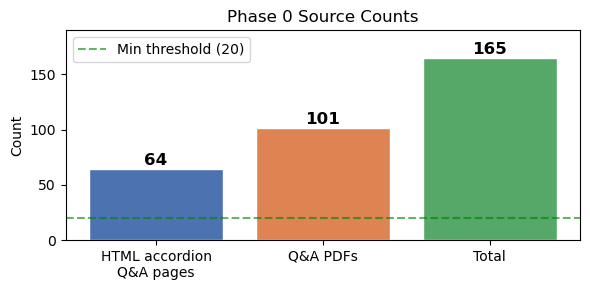

In [5]:
fig, ax = plt.subplots(figsize=(6, 3))
labels = ['HTML accordion\nQ&A pages', 'Q&A PDFs', 'Total']
values = [len(html_rows), len(pdf_rows), len(rows)]
colors = ['#4c72b0', '#dd8452', '#55a868']
bars = ax.bar(labels, values, color=colors, edgecolor='white')
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, str(val),
            ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_ylabel('Count')
ax.set_title('Phase 0 Source Counts')
ax.axhline(20, color='green', linestyle='--', alpha=0.6, label='Min threshold (20)')
ax.legend()
ax.set_ylim(0, max(values) * 1.15)
plt.tight_layout()
plt.savefig(str(ROOT / 'scripts' / 'fig1_source_counts.png'), dpi=120)
plt.show()


## Figure 2 — Topic cluster distribution


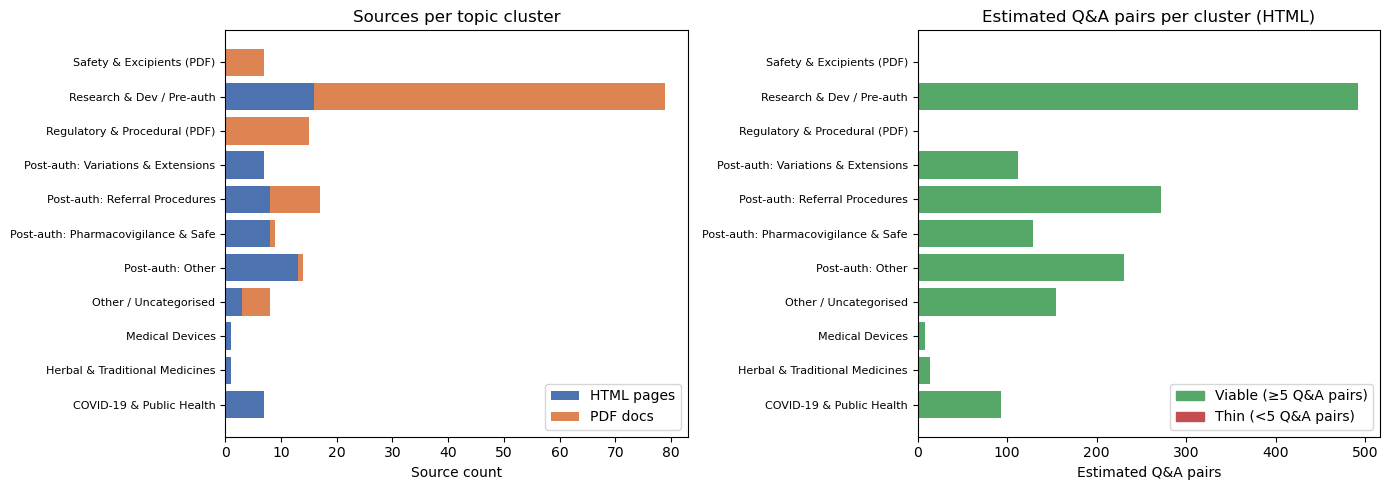

In [6]:
CLUSTERS = [
    ('COVID-19 & Public Health', ['covid','coronavirus','public-health-threat']),
    ('Post-auth: Variations & Extensions', ['variations-including-extensions','worksharing','extensions-marketing','type-ia-variations','type-ib-variations','type-ii-variations','grouping-variations']),
    ('Post-auth: Referral Procedures', ['referral-procedures','article-31','article-30','article-13','article-20','article-29','article-107']),
    ('Post-auth: Pharmacovigilance & Safety', ['pharmacovigilance','risk-management-plan','post-authorisation-efficacy','post-authorisation-safety']),
    ('Post-auth: Other', ['post-authorisation','medicine-shortage','parallel-distribution','transfer-marketing','transparency','renewal','paediatric','orphan']),
    ('Research & Dev / Pre-auth', ['research-development','research-and-development','clinical-trial','compliance-research','scientific-guideline']),
    ('Safety & Excipients (PDF)', ['nitrosamine','excipient','impurit','genotox','toxic','angiotensin','benzoic','benzyl','sodium-laurilsulfate','nsaid','viral']),
    ('Regulatory & Procedural (PDF)', ['regulatory-procedural','ich-','common-technical-document','ctd','eudravigilance','psusa']),
    ('Herbal & Traditional Medicines', ['herbal','traditional-herbal']),
    ('Medical Devices', ['medical-device','ancillary-medicinal']),
]

def assign_cluster(url):
    u = url.lower()
    for name, kws in CLUSTERS:
        if any(k in u for k in kws):
            return name
    return 'Other / Uncategorised'

cluster_html = defaultdict(list)
cluster_pdf  = defaultdict(list)
for r in html_rows: cluster_html[assign_cluster(r['url'])].append(r)
for r in pdf_rows:  cluster_pdf[assign_cluster(r['url'])].append(r)
all_clusters = sorted(set(cluster_html) | set(cluster_pdf))

html_counts = [len(cluster_html.get(c, [])) for c in all_clusters]
pdf_counts  = [len(cluster_pdf.get(c, []))  for c in all_clusters]
qa_counts   = [sum(int(r['q_count_estimate']) for r in cluster_html.get(c,[]) if r['q_count_estimate']) for c in all_clusters]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: page counts by cluster
ax = axes[0]
y = range(len(all_clusters))
ax.barh(y, html_counts, label='HTML pages', color='#4c72b0')
ax.barh(y, pdf_counts, left=html_counts, label='PDF docs', color='#dd8452')
ax.set_yticks(list(y))
ax.set_yticklabels([c[:35] for c in all_clusters], fontsize=8)
ax.set_xlabel('Source count')
ax.set_title('Sources per topic cluster')
ax.legend()

# Right: estimated Q&A pairs per cluster (HTML only)
ax = axes[1]
colors = ['#c44e52' if q < 5 else '#55a868' for q in qa_counts]
ax.barh(list(y), qa_counts, color=colors)
ax.set_yticks(list(y))
ax.set_yticklabels([c[:35] for c in all_clusters], fontsize=8)
ax.set_xlabel('Estimated Q&A pairs')
ax.set_title('Estimated Q&A pairs per cluster (HTML)')
thin = mpatches.Patch(color='#c44e52', label='Thin (<5 Q&A pairs)')
ok   = mpatches.Patch(color='#55a868', label='Viable (≥5 Q&A pairs)')
ax.legend(handles=[ok, thin])

plt.tight_layout()
plt.savefig(str(ROOT / 'scripts' / 'fig2_topic_clusters.png'), dpi=120)
plt.show()


## Figure 3 — Cross-reference chain completeness


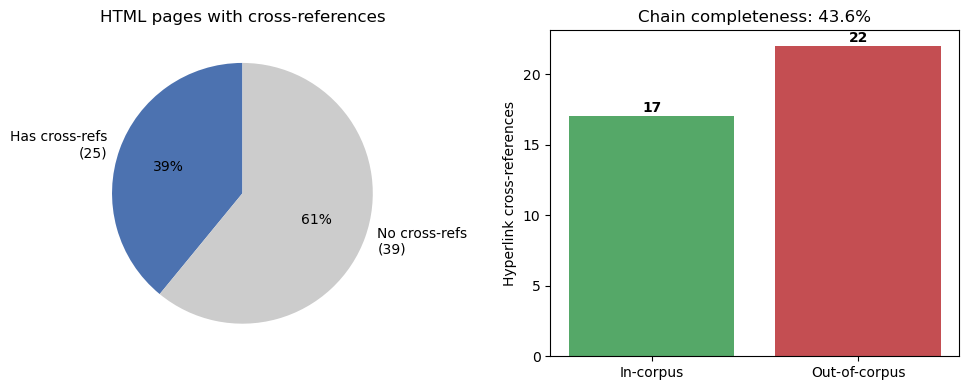

Chain completeness: 43.6% (17/39 links target in-corpus pages)


In [7]:
# Hardcoded from phase0_topic_report.py output
xref_data = {
    'Pages with cross-refs': 25,
    'Pages without cross-refs': 64 - 25,
    'Total link xrefs': 39,
    'In-corpus link xrefs': 17,
    'Out-of-corpus link xrefs': 39 - 17,
}

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ax = axes[0]
ax.pie(
    [xref_data['Pages with cross-refs'], xref_data['Pages without cross-refs']],
    labels=['Has cross-refs\n(25)', 'No cross-refs\n(39)'],
    colors=['#4c72b0', '#cccccc'],
    autopct='%1.0f%%', startangle=90
)
ax.set_title('HTML pages with cross-references')

ax = axes[1]
completeness = xref_data['In-corpus link xrefs'] / xref_data['Total link xrefs'] * 100
ax.bar(['In-corpus', 'Out-of-corpus'],
       [xref_data['In-corpus link xrefs'], xref_data['Out-of-corpus link xrefs']],
       color=['#55a868', '#c44e52'])
ax.set_ylabel('Hyperlink cross-references')
ax.set_title(f'Chain completeness: {completeness:.1f}%')
for i, v in enumerate([xref_data['In-corpus link xrefs'], xref_data['Out-of-corpus link xrefs']]):
    ax.text(i, v + 0.3, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(str(ROOT / 'scripts' / 'fig3_chain_completeness.png'), dpi=120)
plt.show()
print(f'Chain completeness: {completeness:.1f}% ({xref_data["In-corpus link xrefs"]}/{xref_data["Total link xrefs"]} links target in-corpus pages)')


## Phase 0 acceptance criteria


In [8]:
total_qa = sum(int(r['q_count_estimate']) for r in html_rows if r['q_count_estimate'])
n_clusters = 11  # from phase0_topic_report.py
chain_pct  = 43.6

criteria = [
    ('Total sources ≥ 20', len(rows) >= 20, f'{len(rows)} sources'),
    ('Estimated Q&A pairs ≥ 100', total_qa >= 100, f'{total_qa:,} pairs'),
    ('Distinct topic clusters ≥ 3', n_clusters >= 3, f'{n_clusters} clusters'),
    ('Chain completeness documented', True, f'{chain_pct}%'),
]

print('Phase 0 acceptance criteria')
print('-' * 60)
all_pass = True
for desc, passed, detail in criteria:
    icon = '✅' if passed else '❌'
    print(f'  {icon}  {desc:<45} {detail}')
    if not passed: all_pass = False
print('-' * 60)
print(f'  All criteria met: {"✅ YES" if all_pass else "❌ NO"}')


Phase 0 acceptance criteria
------------------------------------------------------------
  ✅  Total sources ≥ 20                            165 sources
  ✅  Estimated Q&A pairs ≥ 100                     1,506 pairs
  ✅  Distinct topic clusters ≥ 3                   11 clusters
  ✅  Chain completeness documented                 43.6%
------------------------------------------------------------
  All criteria met: ✅ YES


---

## ✏️ DECISION  ← Fill this in

> **Owner: SME (you)**  
> Replace the placeholder below with your decision and rationale, then commit.

**Decision: `GO` / `NO-GO`** ← replace with one of these

**Rationale:**
```
[Write 2–5 sentences here:
 - Are the source counts sufficient?
 - Are the topic clusters representative of EMA human-regulatory Q&A?
 - Is the chain completeness acceptable?
 - Any scope changes before Phase 1?]
```

**Date:**  

---

*After filling in this cell, run:*
```bash
git add scripts/phase0_scope_decision.ipynb
git commit -m 'TASK-003: Phase 0 go/no-go decision — GO'
```
*(Nothing in Phase 1 starts until this commit exists with a GO decision.)*



The project scope s clear. The clustes are represantive and the chain completenes is ok. This is a Go
